# Notebook 1 — Préparation des données IMDb 

## Objectif
Dans ce projet, l'objectif est de prédire le genre d'un film en fonction de ses caractéristiques numériques telles que le nombre de votes, la popularité et la note moyenne. Nous allons utiliser un modèle de Naive Bayes pour effectuer cette prédiction.

Le pipeline de préparation retenu est donc le suivant :

1. chargement du dataset brut ;
2. contrôle de structure et de qualité ;
3. sélection des variables utiles au sujet ;
4. traitement des valeurs manquantes ;
5. réduction du champ `Genre` à son **genre principal** ;
6. limitation aux genres les plus représentés pour éviter des classes rares ;
7. encodage de la variable cible ;
8. export d'un dataset `processed` prêt pour l'entraînement.

## Fichiers attendus dans le projet
Ce notebook suppose l'organisation suivante :

```text
projet-naive-bayes-imdb/
├── data/
│   ├── raw/
│   │   └── movies.csv
│   └── processed/
├── notebooks/
└── src/
```


In [306]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Définition des chemins

On utilise des chemins relatifs pour garder le notebook portable au sein du projet.


In [307]:
PROJECT_ROOT = Path.cwd().resolve().parent
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "movies.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH, PROCESSED_DIR

(WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/raw/movies.csv'),
 WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/processed'))

## 2. Chargement du dataset brut

In [308]:
columns_to_use = [
    "year",
    "rating",
    "certificate",
    "duration",
    "genre",
    "votes",
    "gross_income"
]

df_raw = pd.read_csv(
    RAW_PATH,
    usecols=columns_to_use,
    dtype={col: "object" for col in columns_to_use},
    low_memory=True
)

df_raw.head()

,year,rating,certificate,duration,genre,votes,gross_income
0,(2015 TV Special),4.0,TV-MA,94 min,"Adult, News",124.0,0
1,(2008 Video),3.8,Not Certified,88 min,Adult,174.0,0
2,(2011 TV Special),5.7,Not Certified,83 min,"Adult, News",39.0,0
3,(2017 TV Special),4.9,TV-MA,87 min,"Adult, News",225.0,0
4,(2014 TV Special),6.7,R,82 min,"Adult, News",101.0,0


In [309]:
print(f"Dimensions : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
df_raw.info()

Dimensions : 2590932 lignes × 7 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590932 entries, 0 to 2590931
Data columns (total 7 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   year          object
 1   rating        object
 2   certificate   object
 3   duration      object
 4   genre         object
 5   votes         object
 6   gross_income  object
dtypes: object(7)
memory usage: 138.4+ MB


## 3. Audit global des données



### 3.1 Dimensions

In [310]:
print(f"Dimensions du dataset brut : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")

Dimensions du dataset brut : 2590932 lignes × 7 colonnes


### 3.2 Structure

In [311]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2590932 entries, 0 to 2590931
Data columns (total 7 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   year          object
 1   rating        object
 2   certificate   object
 3   duration      object
 4   genre         object
 5   votes         object
 6   gross_income  object
dtypes: object(7)
memory usage: 138.4+ MB


### 3.3 Valeurs manquantes

In [312]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing.to_frame("nb_valeurs_manquantes")

,nb_valeurs_manquantes
year,0
rating,0
certificate,0
duration,0
genre,0
votes,0
gross_income,0


### 3.4 Statistiques descriptives initiales

In [313]:
df_raw.describe(include="all")

,year,rating,certificate,duration,genre,votes,gross_income
count,2590932,2590932,2590932,2590932,2590932,2590932,2590932
unique,3598,92,42,711,3438,20604,10655
top,(2100 - ),11.0,Not Certified,0 min,Game-Show,0,0
freq,53620,1960395,2042014,1608346,143280,1960361,2548798


### 3.5 Duplicats exacts

In [314]:
df_raw.duplicated().sum()

1786041

### 3.6 Supression des duplicats exacts

In [315]:
df = df_raw.drop_duplicates().copy()
print(f"Dimensions après suppression des doublons exacts : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dimensions après suppression des doublons exacts : 804891 lignes × 7 colonnes


## 4. Nettoyage des variables


### 4.1 Nettoyage de gross_income

In [316]:
def clean_gross_income(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["", "nan", "None"]:
        return np.nan

    if "M" in x:
        x = x.replace("$", "").replace("M", "")
        try:
            return float(x) * 1_000_000
        except:
            return np.nan

    x = x.replace("$", "").replace(",", "").replace(" ", "")

    try:
        return float(x)
    except:
        return np.nan

In [317]:
df["gross_income_clean"] = df["gross_income"].apply(clean_gross_income)

### 4.2 Nettoyage rating

In [318]:
df["rating"] = df["rating"].astype(str).str.strip()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

### 4.3 Nettoyage votes

In [319]:
df["votes"] = df["votes"].astype(str).str.strip()
df["votes"] = df["votes"].str.replace(",", "", regex=False)
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

### 4.4 Nettoyage year

In [320]:
df["year"] = df["year"].astype(str).str.strip()

#Extraire les 4 chiffres de l'année
df["year"] = df["year"].str.extract(r"(\d{4})", expand=False)

df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [321]:
df["year"] = df["year"].astype(str).str.strip()
df["year"] = pd.to_numeric(df["year"], errors="coerce")

### 4.5 Nettoyage duration

In [322]:
df["duration"] = df["duration"].astype(str).str.strip()
df["duration"] = df["duration"].str.replace("min", "", regex=False).str.strip()
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

### 4.6 Nettoyage certificate

In [323]:
df["certificate"] = df["certificate"].astype(str).str.strip()
df["certificate"] = df["certificate"].replace(["nan", "None", ""], np.nan)
df["certificate"] = df["certificate"].fillna("Unknown")

### 4.7 Gestion des valeurs manquantes

In [324]:
df = df.dropna(subset=["year","rating","duration","genre","votes","gross_income_clean"]).copy()


### 4.8 Filtrage de cohérence

In [325]:
df = df[
    (df["year"] > 1900) &
    (df["rating"] >= 0) &
    (df["votes"] >= 0) &
    (df["duration"] > 0) &
    (df["gross_income_clean"] >= 0)
].copy()

## 5.Transformation des variables numériques



### 5.1 Transformation logarithmique

In [326]:
df["votes"] = df["votes"].astype(str).str.strip()
df["votes"] = df["votes"].str.replace(",", "", regex=False)
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

In [327]:
df["votes_log"] = np.log1p(df["votes"])
df["gross_income_log"] = np.log1p(df["gross_income_clean"])

In [328]:
df["gross_income_log"].describe()

count   619,963.000
mean          0.842
std           3.331
min           0.000
25%           0.000
50%           0.000
75%           0.000
max          20.658
Name: gross_income_log, dtype: float64

In [329]:
df["gross_income_log"].value_counts().head(10)

gross_income_log
0.000     580943
13.816       115
9.210         92
15.000        64
15.202        58
14.078        53
13.122        50
13.998        49
14.914        49
13.459        46
Name: count, dtype: int64

### 5.2 Vérification des distributions

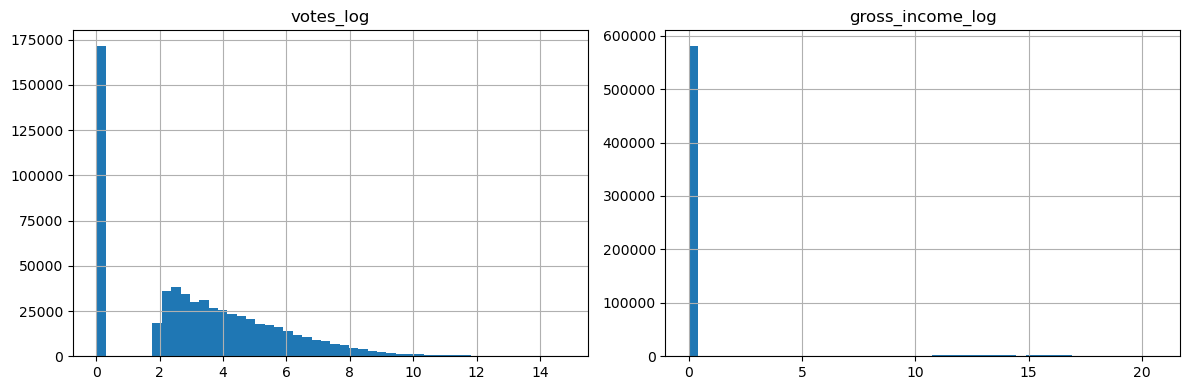

In [330]:
df[["votes_log", "gross_income_log"]].hist(bins=50, figsize=(12, 4))
plt.tight_layout()
plt.show()


Une transformation logarithmique a été appliquée afin de :
- réduire l'effet des valeurs extrêmes ;
- stabiliser la variance ;
- améliorer les performances du modèle.

## 6. Nettoyage de la variable cible


In [331]:
df["genre"] = df["genre"].astype(str).str.split(",").str[0].str.strip()

## 7. Filtrage des classes


In [332]:
genre_counts = df["genre"].value_counts()

TOP_N_GENRES = 4
top_genres = genre_counts.nlargest(TOP_N_GENRES).index.tolist()

df = df[df["genre"].isin(top_genres)].copy()

df["genre"].value_counts()

genre
Animation      102184
Short           93304
Action          68304
Documentary     58934
Name: count, dtype: int64

## 8. Encodage

In [333]:
df["votes_log"] = np.log1p(df["votes"])
df["gross_income_log"] = np.log1p(df["gross_income_clean"])

In [334]:
df["certificate_encoded"] = df["certificate"].astype("category").cat.codes

In [335]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["genre_encoded"] = label_encoder.fit_transform(df["genre"])

In [336]:
label_mapping = pd.DataFrame({
    "genre": label_encoder.classes_,
    "genre_encoded": range(len(label_encoder.classes_))
})

label_mapping

,genre,genre_encoded
0,Action,0
1,Animation,1
2,Documentary,2
3,Short,3


In [337]:
final_cols = [
    "year",
    "rating",
    "duration",
    "votes_log",
    "gross_income_log",
    "certificate_encoded",
    "genre",
    "genre_encoded"
]

df[final_cols].isna().sum()

year                   0
rating                 0
duration               0
votes_log              0
gross_income_log       0
certificate_encoded    0
genre                  0
genre_encoded          0
dtype: int64

## 9. Dataset final



In [338]:
df_final = df[[
    "year",
    "rating",
    "duration",
    "votes_log",
    "gross_income_log",
    "certificate_encoded",
    "genre",
    "genre_encoded" 
]].copy()

## 10. Validation finale

In [339]:
print(df_final.shape)
print(df_final["genre"].value_counts())
print(df_final.isna().sum())

(322726, 8)
genre
Animation      102184
Short           93304
Action          68304
Documentary     58934
Name: count, dtype: int64
year                   0
rating                 0
duration               0
votes_log              0
gross_income_log       0
certificate_encoded    0
genre                  0
genre_encoded          0
dtype: int64


In [340]:
df_final.describe()

,year,rating,duration,votes_log,gross_income_log,certificate_encoded,genre_encoded
count,"322,726.000","322,726.000","322,726.000","322,726.000","322,726.000","322,726.000","322,726.000"
mean,"2,003.764",8.280,37.649,2.814,0.593,18.215,1.549
std,20.403,2.191,39.028,2.510,2.844,7.061,1.118
min,"1,901.000",1.000,1.000,0.000,0.000,0.000,0.000
25%,"1,998.000",6.800,11.000,0.000,0.000,14.000,1.000
50%,"2,010.000",7.800,24.000,2.708,0.000,14.000,1.000
75%,"2,015.000",11.000,50.000,4.407,0.000,27.000,3.000
max,"2,100.000",11.000,999.000,14.761,20.658,35.000,3.000


In [341]:
df_final["genre"].value_counts()

genre
Animation      102184
Short           93304
Action          68304
Documentary     58934
Name: count, dtype: int64

In [342]:
df_final.isna().sum()

year                   0
rating                 0
duration               0
votes_log              0
gross_income_log       0
certificate_encoded    0
genre                  0
genre_encoded          0
dtype: int64

## 11. Export 

Le notebook d'entraînement utilisera exclusivement ces fichiers :
- `movies_clean.csv` : dataset final prêt à l'emploi ;
- `genre_label_mapping.csv` : table de correspondance entre labels texte et labels numériques.


In [343]:
processed_path = PROCESSED_DIR / "movies_clean.csv"
mapping_path = PROCESSED_DIR / "genre_label_mapping.csv"

df_final.to_csv(processed_path, index=False)
label_mapping.to_csv(mapping_path, index=False)

processed_path, mapping_path

(WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/processed/movies_clean.csv'),
 WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/data/processed/genre_label_mapping.csv'))

## 12. Conclusion de préparation


À l'issue de ce notebook :

- les chemins du projet ont été définis de manière reproductible ;
- les colonnes pertinentes (`rating`, `votes`, `genre`, `gross_income`) ont été isolées ;
- les formats hétérogènes des variables numériques ont été nettoyés et convertis ;
- la variable `gross_income` a été normalisée via une fonction de nettoyage robuste ;
- les valeurs manquantes et incohérentes ont été traitées ;
- les distributions asymétriques ont été corrigées via des transformations logarithmiques ;
- le champ `genre` a été simplifié en cible mono-classe ;
- les classes très rares ont été écartées afin de stabiliser le modèle ;
- la variable cible a été encodée ;
- le dataset final propre a été exporté vers `data/processed/`.

Le notebook suivant pourra maintenant se concentrer sur :

- le chargement de la donnée `processed` ;
- la séparation entraînement / test ;
- l'entraînement du modèle Naive Bayes ;
- l'évaluation des performances ;
- l'analyse critique des résultats obtenus.